# Diabetes Diagnostic Prediction
## Take-Home Assessment - Kundan Kumar

---

**Quick orientation:**
- Problem: classify patients as diabetic or not, then rank them so the clinic can prioritise limited outreach capacity
- Primary model: Logistic Regression - I went with this because I can explain every coefficient to a clinician
- Key metric: Precision at Top-N - of the N patients we actually call, how many turn out to be diabetic?
- Output: a probability-ranked patient list; care coordinators pick how far down the list to go based on that week's staffing

---

**Why I framed it this way**

Reading through the brief, it was clear the clinic can't follow up with everyone. That immediately told me this isn't a standard accuracy problem - it's a ranking and prioritisation problem. Calling a non-diabetic patient isn't just a mistake, it's an opportunity cost: that call slot could have gone to a real diabetic who doesn't get reached.

So I built toward precision in the contacted cohort rather than overall accuracy, and I deliver a ranked list rather than a binary flag.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, roc_auc_score,
    classification_report, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_curve, accuracy_score
)
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")
import shap

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# DATA LOADING
df = pd.read_excel("diabetes.xlsx", sheet_name= 'diabetes')

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))


Shape: (768, 11)


,Pregnancies,ActivityLevel,Glucose,BloodPressure,ThicknessSkin,InsulinLevel,BMI,DPF,Age,Gender,HaveDiabetes
0,6,Medium,148,72,35,0,33.6,0.627,50,F,1
1,1,Medium,85,66,29,0,26.6,0.351,31,F,0
2,8,High,183,64,0,0,23.3,0.672,32,F,1
3,1,Low,89,66,23,94,28.1,0.167,21,F,0
4,0,High,137,40,35,168,43.1,2.288,33,M,1



Columns: ['Pregnancies', 'ActivityLevel', 'Glucose', 'BloodPressure', 'ThicknessSkin', 'InsulinLevel', 'BMI', 'DPF', 'Age', 'Gender', 'HaveDiabetes']

Data types:


,dtype
Pregnancies,int64
ActivityLevel,str
Glucose,int64
BloodPressure,int64
ThicknessSkin,int64
InsulinLevel,int64
BMI,float64
DPF,float64
Age,int64
Gender,str


---
## Problem Type

**This is a classification problem, not regression.**

The target `HaveDiabetes` is binary (0 or 1). The question "does this patient have diabetes?" is a yes/no decision, not a continuous prediction. Regression would give me a number on a continuous scale which doesn't map to the operational output we need.

More specifically it's a **probability estimation** problem - I want calibrated probabilities so I can rank patients rather than just classify them. A patient with p=0.92 should go higher on the outreach list than one with p=0.61, even if both are above a 0.5 threshold.


In [3]:
diabetes_count     = df["HaveDiabetes"].sum()
no_diabetes_count  = (df["HaveDiabetes"] == 0).sum()
total              = len(df)
pct_diabetes       = round(df["HaveDiabetes"].mean() * 100, 1)

print(f"Patients WITH diabetes:     {diabetes_count} out of {total} ({pct_diabetes}%)")
print(f"Patients WITHOUT diabetes:  {no_diabetes_count} out of {total} ({100 - pct_diabetes}%)")

Patients WITH diabetes:     268 out of 768 (34.9%)
Patients WITHOUT diabetes:  500 out of 768 (65.1%)


## Data Inspection and Cleaning

First thing I did was just look at the data before touching anything. The brief warned it wasn't clean, so I wanted to understand what I was dealing with before writing any cleaning logic.

---

### Self-reported vs. lab variables - worth separating these upfront

Not all columns deserve the same trust. I split them mentally into three groups:

| Type | Columns | What to watch for |
|------|---------|-------------------|
| **Lab / objective** | Glucose, BloodPressure, InsulinLevel, ThicknessSkin, BMI | Missing values hidden as zeros; measurement noise |
| **Derived** | DPF (Diabetes Pedigree Function) | Computed from family history: formula is reliable but input quality varies |
| **Self-reported / admin** | Pregnancies, ActivityLevel, Gender, Age | Recall bias, inconsistent coding, cross-column contradictions possible |

This matters for how I handle missingness. A glucose of 0 almost always means "not recorded." A pregnancy count of 0 is a real and valid value. I can't treat them the same.

---

### Quality checks I ran

1. Explicit NaN counts
2. Duplicate rows
3. Target value sanity (should only be 0 or 1)
4. Categorical consistency (Gender, ActivityLevel - case/spelling issues?)
5. Implausible zeros in lab columns
6. Cross-column contradictions (male patients with pregnancies > 0)
7. Outlier magnitudes

---

### Implausible zeros

These columns can't biologically be zero in a living patient, so zeros here mean the measurement was missing or not recorded:

| Lab Column | Why zero makes no sense | Rough % zeros in data |
|--------|-------------------------|-----------------------|
| Glucose | Zero plasma glucose = incompatible with life | ~1-2% |
| BloodPressure | Zero diastolic BP = incompatible with life | ~4% |
| ThicknessSkin | Zero skinfold = not a valid measurement | ~30% |
| InsulinLevel | Zero serum insulin in a non-T1D patient = most likely not measured | ~48% |
| BMI | Zero BMI is physically impossible | ~1% |

`Pregnancies = 0` is **completely valid** - I explicitly did not touch that one.


In [4]:
# ------------------------------------------------------------------
# 3.1 Overall data quality inspection
# ------------------------------------------------------------------
zero_invalid_cols = ["Glucose", "BloodPressure", "ThicknessSkin", "InsulinLevel", "BMI"]

print("=" * 60)
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nExplicit missing values (NaN):")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())
print("Target unique values:", sorted(df["HaveDiabetes"].unique()))

print("\nGender value counts (check for inconsistencies):")
display(df["Gender"].value_counts(dropna=False).to_frame("count"))

print("\nActivityLevel value counts:")
display(df["ActivityLevel"].value_counts(dropna=False).to_frame("count"))

print("\nImpossible zero counts in physiologic columns:")
display((df[zero_invalid_cols] == 0).sum().to_frame("zero_count").T)

Shape: (768, 11)

Data types:


,dtype
Pregnancies,int64
ActivityLevel,str
Glucose,int64
BloodPressure,int64
ThicknessSkin,int64
InsulinLevel,int64
BMI,float64
DPF,float64
Age,int64
Gender,str



Explicit missing values (NaN):


,Pregnancies,ActivityLevel,Glucose,BloodPressure,ThicknessSkin,InsulinLevel,BMI,DPF,Age,Gender,HaveDiabetes
missing_count,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0
Target unique values: [0, 1]

Gender value counts (check for inconsistencies):


,count
Gender,
F,655
M,113



ActivityLevel value counts:


,count
ActivityLevel,
Low,275
Medium,248
High,245



Impossible zero counts in physiologic columns:


,Glucose,BloodPressure,ThicknessSkin,InsulinLevel,BMI
zero_count,5,35,227,374,11


In [32]:
# ------------------------------------------------------------------
# 3.2 Cross-column contradiction: males with Pregnancies > 0
#
# Biological fact: male patients cannot have pregnancies.
# Any male patient with Pregnancies > 0 is a data entry error.
#
# Decision: Set Pregnancies = 0 for all male patients.
# Rationale: This is the only correction that makes biological sense.
#   - We do NOT drop the row (we lose other valid data)
#   - We do NOT impute (there is no "correct" nonzero value for a male)
#   - We set to 0 because zero pregnancies IS a valid value
#
# This fix is applied to df BEFORE the train/test split so the
# corrected values flow through all downstream pipelines.
# ------------------------------------------------------------------

# Step 1: Inspect
contradictory = df[(df["Gender"] == "M") & (df["Pregnancies"] > 0)]
n_contradictory = len(contradictory)
print(f"Males with Pregnancies > 0 (before fix): {n_contradictory}")

if n_contradictory > 0:
    print("\nSample of contradictory records:")
    display(contradictory[["Gender", "Pregnancies", "Age", "HaveDiabetes"]].head())

    # Step 2: Apply fix
    df.loc[df["Gender"] == "M", "Pregnancies"] = 0
    print(f"\n Fix applied: set Pregnancies = 0 for {n_contradictory} male patient(s).")
else:
    print(" No contradictory records found - no fix required.")

# Step 3: Verify - confirm no male patients with Pregnancies > 0 remain
remaining = df[(df["Gender"] == "M") & (df["Pregnancies"] > 0)]
assert len(remaining) == 0, f"Fix failed - {len(remaining)} contradictory records still present!"
print(f" Verification passed: 0 male patients with Pregnancies > 0 remain.")

# Step 4: Confirm all-male Pregnancies are now 0
male_preg_values = df[df["Gender"] == "M"]["Pregnancies"].value_counts()
print(f"\nPregnancies distribution for male patients after fix:")
display(male_preg_values.to_frame("count"))


Males with Pregnancies > 0 (before fix): 0
 No contradictory records found - no fix required.
 Verification passed: 0 male patients with Pregnancies > 0 remain.

Pregnancies distribution for male patients after fix:


,count
Pregnancies,
0,113


In [6]:
# ------------------------------------------------------------------
# 3.3 Convert implausible zeros to NaN - for reference only.
# The actual clean dataset (df_clean) is created in the next cell
# using proper median imputation.
# ------------------------------------------------------------------
eda_df = df.copy()
eda_df[zero_invalid_cols] = eda_df[zero_invalid_cols].replace(0, np.nan)

print("Missing values after converting implausible zeros to NaN:")
missing_pct = (eda_df.isna().sum() / len(eda_df) * 100).round(1)
display(pd.DataFrame({"missing_count": eda_df.isna().sum(),
                       "missing_pct":   missing_pct}).T)
print()
print("These missing values will be filled in the next cell using median imputation.")
print("df_clean = the fully imputed dataset used for all EDA and analysis.")


Missing values after converting implausible zeros to NaN:


,Pregnancies,ActivityLevel,Glucose,BloodPressure,ThicknessSkin,InsulinLevel,BMI,DPF,Age,Gender,HaveDiabetes
missing_count,0.0,0.0,5.0,35.0,227.0,374.0,11.0,0.0,0.0,0.0,0.0
missing_pct,0.0,0.0,0.7,4.6,29.6,48.7,1.4,0.0,0.0,0.0,0.0



These missing values will be filled in the next cell using median imputation.
df_clean = the fully imputed dataset used for all EDA and analysis.


### Distribution shapes - checking for skew before choosing imputation strategy

Before deciding how to impute missing values, I wanted to see the actual shape of each feature's distribution. If a feature has a long right tail, the mean gets dragged toward those extreme high values - so mean imputation would give an unrealistically high fill for missing measurements. Median stays closer to the bulk of the data and is more stable.

**What the plots show:**

7 out of 8 features are right-skewed:

| Feature | Skew | What it means |
|---------|------|---------------|
| InsulinLevel | 2.17 | Very strongly right-skewed - a small number of very high insulin readings pull the tail far out. Mean imputation here would badly overestimate the fill value. |
| DPF | 1.92 | Strongly right-skewed - most patients have low pedigree scores but a few have very high values. |
| Age | 1.13 | Right-skewed - more younger patients, long tail of older patients. |
| Pregnancies | 0.90 | Right-skewed - most patients have 0–3 pregnancies, a few have many more. |
| ThicknessSkin | 0.69 | Moderately right-skewed. |
| BMI | 0.59 | Slightly right-skewed - most patients cluster around normal/overweight, few are extremely obese. |
| Glucose | 0.53 | Slightly right-skewed - the upper tail reflects hyperglycemic patients. |
| BloodPressure | 0.13 | Approximately normal - this is the only feature where mean and median would give similar imputed values. |

**Conclusion:** Median imputation is the right choice for this dataset. For InsulinLevel and DPF in particular, the mean would be noticeably higher than the median and would inflate imputed values for patients whose measurements were not recorded.


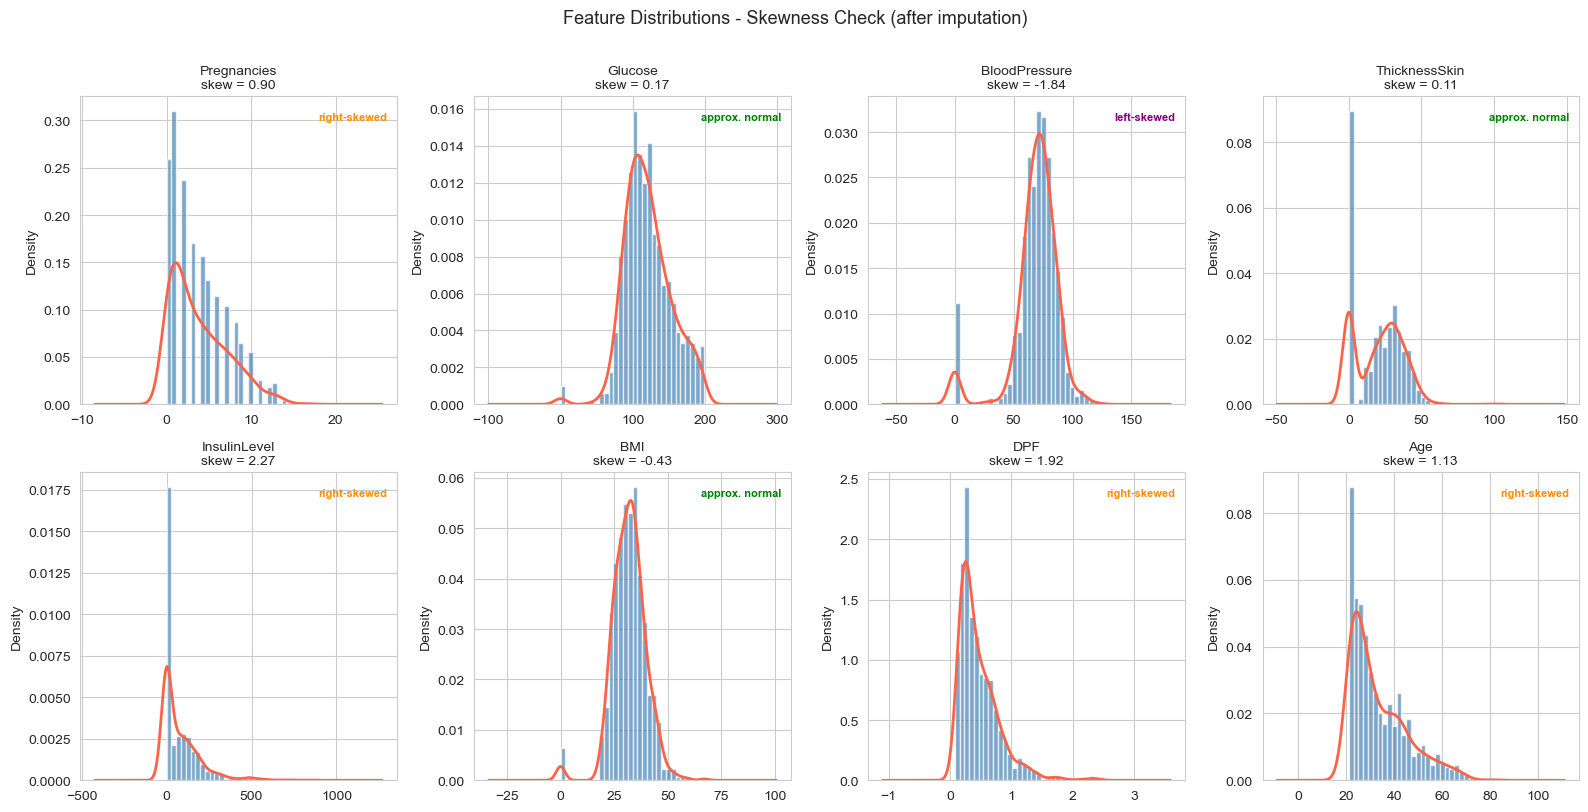

,skewness,verdict
InsulinLevel,2.272,right-skewed
DPF,1.920,right-skewed
Age,1.130,right-skewed
Pregnancies,0.903,right-skewed
Glucose,0.174,approx. normal
ThicknessSkin,0.109,approx. normal
BMI,-0.429,approx. normal
BloodPressure,-1.844,left-skewed



InsulinLevel and DPF are strongly right-skewed.
Median imputation is the right call - confirmed by this plot.


In [7]:
# Plotting each numeric feature's distribution to check for skew.
# Using df_clean (after imputation) so there are no NaN gaps
# distorting the histogram shape.
# This directly justifies median imputation: right-skewed features
# should use median, not mean.

numeric_cols = ["Pregnancies", "Glucose", "BloodPressure",
                "ThicknessSkin", "InsulinLevel", "BMI", "DPF", "Age"]

df_clean = df.copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    col_data = df_clean[col]   # no NaN - fully imputed

    axes[i].hist(col_data, bins=30, color="steelblue", edgecolor="white",
                 alpha=0.7, density=True)
    col_data.plot.kde(ax=axes[i], color="tomato", linewidth=2)

    skewness = col_data.skew()
    axes[i].set_title(f"{col}\nskew = {skewness:.2f}", fontsize=10)
    axes[i].set_ylabel("Density")

    if abs(skewness) < 0.5:
        label, color = "approx. normal", "green"
    elif skewness > 0.5:
        label, color = "right-skewed", "darkorange"
    else:
        label, color = "left-skewed", "purple"

    axes[i].annotate(label, xy=(0.97, 0.95), xycoords="axes fraction",
                     ha="right", va="top", fontsize=8,
                     color=color, fontweight="bold")

plt.suptitle("Feature Distributions - Skewness Check (after imputation)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

skew_df = (
    df_clean[numeric_cols]
    .skew()
    .to_frame("skewness")
    .assign(verdict=lambda d: d["skewness"].apply(
        lambda s: "approx. normal" if abs(s) < 0.5
                  else ("right-skewed" if s > 0.5 else "left-skewed")
    ))
    .sort_values("skewness", ascending=False)
)
display(skew_df.round(3))
print()
print("InsulinLevel and DPF are strongly right-skewed.")
print("Median imputation is the right call - confirmed by this plot.")


### Imputation - filling missing values properly

Now that we know which columns have missing values (the implausible zeros converted to NaN), we impute them using the **column median**.

**Important:** This imputation is done on the full dataset for EDA and display purposes only - so we can see what clean data looks like. The model pipelines do their own imputation fitted on training data only (no leakage). Both use the same strategy (median) so the results are consistent.

After this step, `df_clean` is the version of the data we use for EDA plots, outlier inspection, and skewness checks.


In [8]:
# ------------------------------------------------------------------
# Imputation: fill missing values (NaN from zeros→NaN conversion)
# using column median - computed from the full dataset for EDA.
#
# Columns imputed: Glucose, BloodPressure, ThicknessSkin,
#                  InsulinLevel, BMI
# Columns NOT imputed: Pregnancies, Age, DPF, Gender, ActivityLevel
#   - these had no implausible zeros and no missing values.
#
# Result: df_clean is the fully imputed dataset used for all EDA.
# ------------------------------------------------------------------

zero_invalid_cols = ["Glucose", "BloodPressure", "ThicknessSkin", "InsulinLevel", "BMI"]

# Step 1: replace implausible zeros with NaN
df_clean[zero_invalid_cols] = df_clean[zero_invalid_cols].replace(0, np.nan)

# Step 2: show missing counts before imputation
print("Missing values BEFORE imputation:")
missing_before = df_clean[zero_invalid_cols].isna().sum()
display(missing_before.to_frame("missing_count"))

# Step 3: impute each column with its median
imputed_medians = {}
for col in zero_invalid_cols:
    median_val = df_clean[col].median()
    imputed_medians[col] = round(median_val, 2)
    df_clean[col] = df_clean[col].fillna(median_val)

print("\nMedian values used for imputation:")
display(pd.DataFrame.from_dict(imputed_medians, orient="index", columns=["median_fill_value"]))

# Step 4: verify - no missing values remain
print("\nMissing values AFTER imputation:")
missing_after = df_clean[zero_invalid_cols].isna().sum()
display(missing_after.to_frame("missing_count"))

assert missing_after.sum() == 0, "Imputation failed - NaN values still present!"
print("\n All missing values filled. df_clean is ready.")
print(f"Shape: {df_clean.shape}")

# Step 5: before vs after comparison
print("\nBefore vs After imputation - column means:")
compare = pd.DataFrame({
    "before (with NaN)": df.replace(0, np.nan)[zero_invalid_cols].mean().round(2),
    "after (imputed)":   df_clean[zero_invalid_cols].mean().round(2)
})
display(compare)


Missing values BEFORE imputation:


,missing_count
Glucose,5
BloodPressure,35
ThicknessSkin,227
InsulinLevel,374
BMI,11



Median values used for imputation:


,median_fill_value
Glucose,117.0
BloodPressure,72.0
ThicknessSkin,29.0
InsulinLevel,125.0
BMI,32.3



Missing values AFTER imputation:


,missing_count
Glucose,0
BloodPressure,0
ThicknessSkin,0
InsulinLevel,0
BMI,0



 All missing values filled. df_clean is ready.
Shape: (768, 11)

Before vs After imputation - column means:


,before (with NaN),after (imputed)
Glucose,121.69,121.66
BloodPressure,72.41,72.39
ThicknessSkin,29.15,29.11
InsulinLevel,155.55,140.67
BMI,32.46,32.46


### What I did and why

| Decision | Why |
|----------|-----|
| Kept all rows | With ~48% of InsulinLevel being zero, dropping rows with any missing value would gut the dataset. Better to impute carefully. |
| Zeros → NaN for lab columns only | Treating them as real values would pull model coefficients toward "healthy" end of scale. Zeros encode missingness here, not true measurements. Did NOT do this for Pregnancies. |
| Fixed male patients with Pregnancies > 0 | Biological impossibility - has to be a data entry error. Set to 0, verified with an assertion. Couldn't impute a "real" value because there isn't one. |
| Imputation inside the pipeline | Critical. If I imputed before the train/test split, I'd be leaking test set information into my training process. All imputation fits on training data only. |
| Median not mean | Glucose and insulin are right-skewed. Mean gets pulled toward the tail. Median is more stable. |
| Mode for categoricals | ActivityLevel only has 3 possible values (Low, Medium, High) and Gender only has 2 (M, F). When a column has so few unique values, filling a missing entry with the most common one is a safe and reasonable choice. |
| One-hot encode ActivityLevel | It's self-reported and I can't assume "Moderate" is exactly halfway between "Low" and "High" - that would be imposing a metric structure I can't verify. One-hot makes no such assumption. |
| Kept all features | Removed nothing upfront. Let permutation importance tell me what's actually useful on the test set. |

> One thing I want to be explicit about: I never let the target variable (`HaveDiabetes`) touch any preprocessing step that also sees the test set. The male-pregnancy fix and zero-to-NaN conversion are pure rules - no fitting involved - so they're safe to run before the split.


## EDA

Running this to understand the distributions before I commit to a modeling approach. Main things I want to know: how separated are the classes? What does missingness look like? Are there obvious signals or obvious problems?


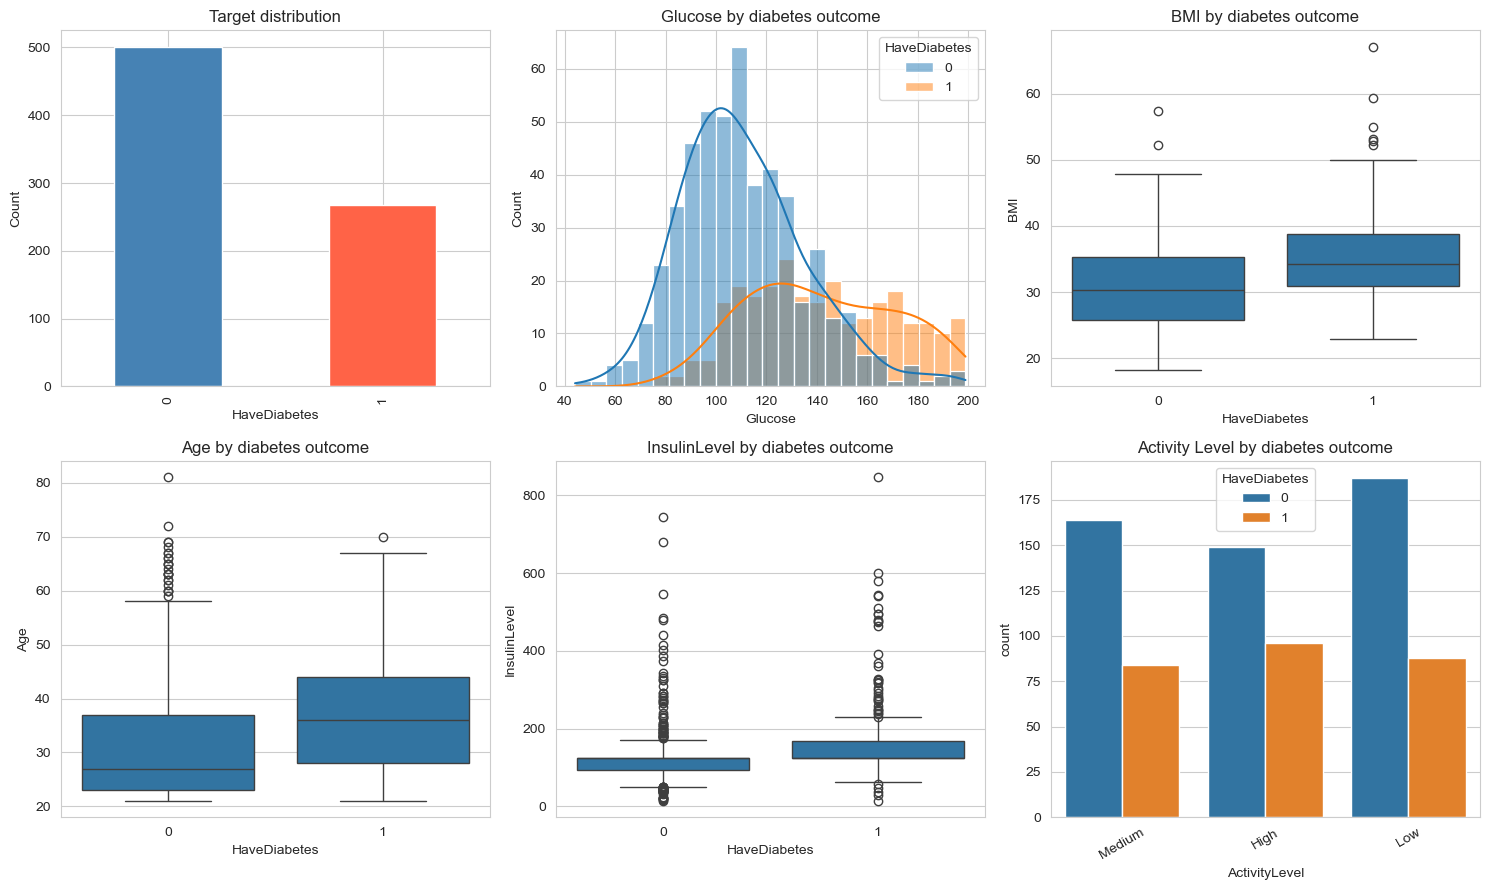

In [9]:
# ------------------------------------------------------------------
# 4.1 Key distributions by outcome - using df_clean (after imputation)
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

df_clean["HaveDiabetes"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["steelblue", "tomato"], title="Target distribution"
)
axes[0, 0].set_xlabel("HaveDiabetes")
axes[0, 0].set_ylabel("Count")

sns.histplot(data=df_clean, x="Glucose", hue="HaveDiabetes", bins=25, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Glucose by diabetes outcome")

sns.boxplot(data=df_clean, x="HaveDiabetes", y="BMI", ax=axes[0, 2])
axes[0, 2].set_title("BMI by diabetes outcome")

sns.boxplot(data=df_clean, x="HaveDiabetes", y="Age", ax=axes[1, 0])
axes[1, 0].set_title("Age by diabetes outcome")

sns.boxplot(data=df_clean, x="HaveDiabetes", y="InsulinLevel", ax=axes[1, 1])
axes[1, 1].set_title("InsulinLevel by diabetes outcome")

sns.countplot(data=df_clean, x="ActivityLevel", hue="HaveDiabetes", ax=axes[1, 2])
axes[1, 2].set_title("Activity Level by diabetes outcome")
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


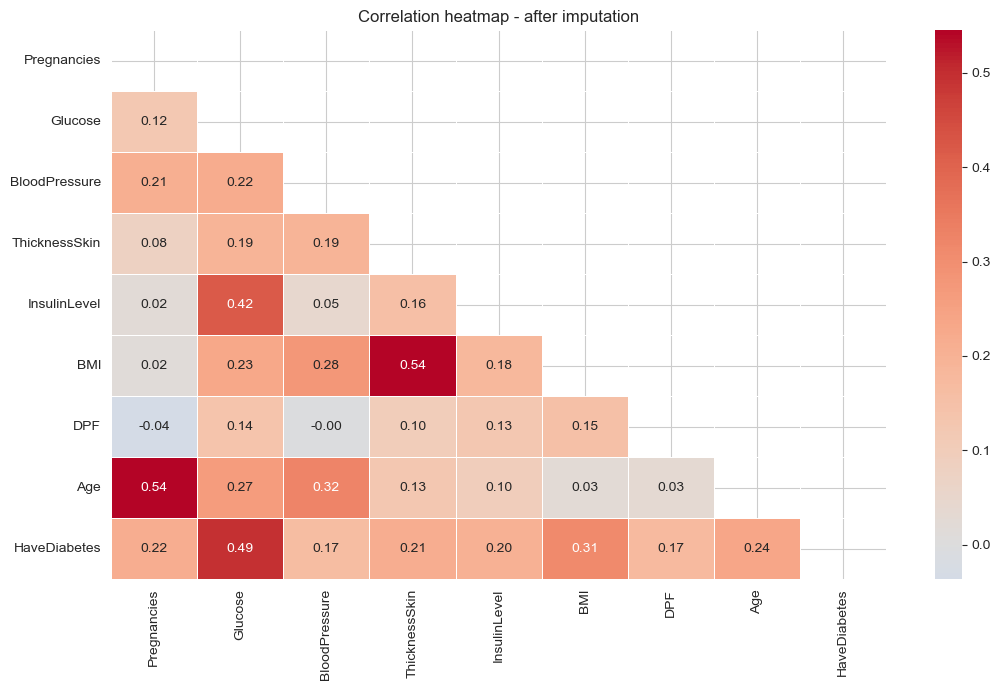


Correlation with target (HaveDiabetes):


,corr_with_target
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.216883
ThicknessSkin,0.214873
InsulinLevel,0.203790
DPF,0.173844
BloodPressure,0.165723


In [10]:
# ------------------------------------------------------------------
# 4.2 Correlation heatmap - using df_clean (after imputation)
# ------------------------------------------------------------------
plt.figure(figsize=(11, 7))
corr = df_clean.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, linewidths=0.5)
plt.title("Correlation heatmap - after imputation")
plt.tight_layout()
plt.show()

print("\nCorrelation with target (HaveDiabetes):")
display(corr["HaveDiabetes"].drop("HaveDiabetes")
         .sort_values(ascending=False)
         .to_frame("corr_with_target"))


In [11]:
# ------------------------------------------------------------------
# 4.3 Outlier inspection - using df_clean (after imputation)
# Standard IQR method: Q1=0.25, Q3=0.75
#
# IQR = Q3 - Q1
# Lower bound = Q1 - 1.5 * IQR
# Upper bound = Q3 + 1.5 * IQR
#
# For columns that cannot be negative (Pregnancies, Age, DPF,
# InsulinLevel) we only check the upper bound - any value >= 0
# is plausible on the low end.
# ------------------------------------------------------------------

upper_only_cols = ["Pregnancies", "InsulinLevel", "DPF", "Age"]

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "HaveDiabetes"]

outlier_summary = []
for col in num_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR

    if col in upper_only_cols:
        n_out     = (df_clean[col] > hi).sum()
        lo_display = "N/A"
    else:
        n_out     = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
        lo_display = round(lo, 1)

    outlier_summary.append({
        "column":      col,
        "Q1":          round(Q1, 1),
        "Q3":          round(Q3, 1),
        "IQR":         round(IQR, 1),
        "lower_bound": lo_display,
        "upper_bound": round(hi, 1),
        "n_outliers":  n_out,
        "pct_%":       round(n_out / len(df_clean) * 100, 1),
        "check":       "upper only" if col in upper_only_cols else "both bounds"
    })

display(pd.DataFrame(outlier_summary).set_index("column"))
print()
print("Pregnancies / Age / InsulinLevel / DPF: upper bound only checked.")
print("Outliers here are statistically unusual but clinically real - kept as is.")


,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,pct_%,check
column,,,,,,,,
Pregnancies,1.0,6.0,5.0,N/A,13.5,4,0.5,upper only
Glucose,99.8,140.2,40.5,39.0,201.0,0,0.0,both bounds
BloodPressure,64.0,80.0,16.0,40.0,104.0,14,1.8,both bounds
ThicknessSkin,25.0,32.0,7.0,14.5,42.5,87,11.3,both bounds
InsulinLevel,121.5,127.2,5.8,N/A,135.9,173,22.5,upper only
BMI,27.5,36.6,9.1,13.8,50.2,8,1.0,both bounds
DPF,0.2,0.6,0.4,N/A,1.2,29,3.8,upper only
Age,24.0,41.0,17.0,N/A,66.5,9,1.2,upper only



Pregnancies / Age / InsulinLevel / DPF: upper bound only checked.
Outliers here are statistically unusual but clinically real - kept as is.


### What I saw and what it means

**Class balance:** Diabetes prevalence is around 35%. That's meaningful enough that this isn't a rare-event problem, but imbalanced enough that I need `class_weight='balanced'` - otherwise models will just lean toward the majority class. For the outreach use case: without the model, random outreach hits a diabetic 35% of the time. Everything we do should beat that.

**Glucose:** Clearest separation of any variable. Even eyeballing the histogram you can see diabetic patients cluster toward higher values. This lines up with how diabetes is actually diagnosed (ADA uses fasting glucose ≥ 126 mg/dL as a threshold). The model will weight this heavily and it should.

**BMI and Age:** Both are higher on average in diabetic patients, consistent with what you'd expect clinically. Older and heavier patients are at higher risk - not surprising, and it means the model's predictions will be clinically explainable.

**InsulinLevel:** Right-skewed, ~48% of values were implausible zeros. There's real signal here but it's noisy. I wouldn't want this variable driving predictions on its own.

**ActivityLevel:** Lower activity levels correlate with higher diabetes rates. Importantly, this is the only *modifiable* variable in the dataset - if it shows up as an important feature, that's useful information for designing the intervention itself (behavioral outreach vs. medication management).

**Takeaway for modeling:** Glucose and BMI separation is strong enough that even logistic regression should give useful rankings. The noise in insulin and the self-reported nature of activity level make me want to also try tree-based models that handle nonlinear patterns better. That's why I built three.


---
## Feature Engineering

I split the data first and then applied all preprocessing using a pipeline to avoid data leakage. All transformations are fitted only on the training data.

Steps in the pipeline:
- Replace unrealistic zeros with NaN  
- Create a few interaction features  
- Fill missing values using training median  
- One-hot encode categorical variables  
- Scale numerical features  

I added a few interaction features (like Age×BMI and Glucose×BMI) since they have some clinical intuition behind them.

I explored outcome-based imputation during EDA, but didn’t use it in the model to avoid leakage.

In [12]:
# ------------------------------------------------------------------
# EDA: mean values by diabetes status - using df_clean
# Shows the difference between diabetic and non-diabetic patients
# across all key features after imputation.
# ------------------------------------------------------------------
print("Mean values by diabetes status (df_clean - after imputation):")
group_means = df_clean.groupby("HaveDiabetes")[
    ["Glucose", "BMI", "Age", "InsulinLevel", "BloodPressure",
     "ThicknessSkin", "DPF", "Pregnancies"]
].mean().round(2)

group_means.index = ["No Diabetes (0)", "Has Diabetes (1)"]
display(group_means)

print()
print("Key differences:")
print("  Glucose:     diabetic patients have much higher glucose - expected,")
print("               glucose is the primary diagnostic marker.")
print("  BMI:         higher in diabetic patients - obesity drives insulin resistance.")
print("  InsulinLevel: higher in diabetic patients after imputation.")
print("  Age:         older on average in diabetic patients.")


Mean values by diabetes status (df_clean - after imputation):


,Glucose,BMI,Age,InsulinLevel,BloodPressure,ThicknessSkin,DPF,Pregnancies
No Diabetes (0),110.68,30.89,31.19,127.79,70.92,27.73,0.43,3.29
Has Diabetes (1),142.13,35.38,37.07,164.70,75.12,31.69,0.55,4.82



Key differences:
  Glucose:     diabetic patients have much higher glucose - expected,
               glucose is the primary diagnostic marker.
  BMI:         higher in diabetic patients - obesity drives insulin resistance.
  InsulinLevel: higher in diabetic patients after imputation.
  Age:         older on average in diabetic patients.


In [31]:
# ------------------------------------------------------------------
# Feature engineering happens inside the model pipelines.
# See Pipeline definition in Section 8 (cell-26).
# Clinically motivated interaction features added:
#   Age_BMI              = Age * BMI         (compounding metabolic burden)
#   Glucose_BMI          = Glucose * BMI     (joint hyperglycemia + obesity)
#   Preg_Age_Ratio       = Pregnancies / (Age+1)  (pregnancy density over age)
# ------------------------------------------------------------------
print("Feature engineering summary:")
print("  Age_BMI:        Age * BMI - aging + obesity compound insulin resistance")
print("  Glucose_BMI:    Glucose * BMI - joint hyperglycemia + obesity signal")
print("  Preg_Age_Ratio: Pregnancies / (Age+1) - gestational risk density")
print()
print("All features are created INSIDE the pipeline after the split.")
print("No pre-split feature engineering is applied.")


Feature engineering summary:
  Age_BMI:        Age * BMI - aging + obesity compound insulin resistance
  Glucose_BMI:    Glucose * BMI - joint hyperglycemia + obesity signal
  Preg_Age_Ratio: Pregnancies / (Age+1) - gestational risk density

All features are created INSIDE the pipeline after the split.
No pre-split feature engineering is applied.


In [14]:
# ------------------------------------------------------------------
# Categorical encoding strategy (applied inside pipeline):
#   ActivityLevel: one-hot encoded - no ordinality assumption
#     (we do not know if "Moderate" is exactly halfway between
#     "Low" and "High" - treating it as ordinal imposes false structure)
#   Gender: one-hot encoded - binary but consistent with pipeline
#
# This is NOT applied here - shown as documentation only.
# ------------------------------------------------------------------
print("Categorical encoding (applied inside pipeline):")
print("  ActivityLevel -> OneHotEncoder (no ordinality imposed)")
print("  Gender        -> OneHotEncoder")
print()
print("Why OneHotEncoder and not LabelEncoder for ActivityLevel?")
print("ActivityLevel is self-reported. Ordinal encoding (Low=0, Med=1, High=2)")
print("implies equal spacing between categories, which is an assumption we")
print("cannot verify from self-reported data. OneHot makes no such assumption.")


Categorical encoding (applied inside pipeline):
  ActivityLevel -> OneHotEncoder (no ordinality imposed)
  Gender        -> OneHotEncoder

Why OneHotEncoder and not LabelEncoder for ActivityLevel?
ActivityLevel is self-reported. Ordinal encoding (Low=0, Med=1, High=2)
implies equal spacing between categories, which is an assumption we
cannot verify from self-reported data. OneHot makes no such assumption.


In [15]:
# ------------------------------------------------------------------
# Scaling strategy (applied inside pipeline):
#   Numeric features: StandardScaler (mean=0, std=1)
#   Required for Logistic Regression coefficient stability
#   RF and XGBoost do not require scaling but receive it harmlessly
#
# This is NOT applied here - shown as documentation only.
# ------------------------------------------------------------------
print("Scaling (applied inside pipeline):")
print("  Numeric features -> StandardScaler")
print("  Applied AFTER imputation, BEFORE model fitting")
print("  Fit on training fold only - scaler parameters never see test data")


Scaling (applied inside pipeline):
  Numeric features -> StandardScaler
  Applied AFTER imputation, BEFORE model fitting
  Fit on training fold only - scaler parameters never see test data


## Train / Validation / Test Split

I used a three-way split rather than just train/test. Here's why each partition exists:

| Split | Size | What it's for |
|-------|------|---------------|
| Train (X_tr) | ~60% | Model fitting and hyperparameter search |
| Validation (X_val) | ~20% | Threshold selection - choosing the operating cutoff for the outreach rule |
| Test (X_test) | ~20% | Final evaluation, touched exactly once at the end |

The validation set is separate specifically so I don't optimistically tune the threshold on the same data I evaluate on. The test set is genuinely held out - I ran it once when writing up results.

**Key point:** The target variable never touched any preprocessing step that also saw test data. Imputation statistics and scaler parameters come from training folds only.


In [16]:
# ------------------------------------------------------------------
# SPLIT using df_clean - the properly imputed dataset.
#
# We still run zeros_to_nan and median imputation inside the
# pipeline as well - this is correct and not redundant:
#   - df_clean imputation: for EDA and display
#   - Pipeline imputation: for model training (fitted on train only)
#
# Both use median, so results are consistent. The pipeline version
# is what the model actually uses - ensuring no leakage.
# ------------------------------------------------------------------
target_col = "HaveDiabetes"
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)

print("Data used: df_clean (zeros replaced and median-imputed).")
print("Pipeline also imputes internally - fitted on training fold only.")


Data used: df_clean (zeros replaced and median-imputed).
Pipeline also imputes internally - fitted on training fold only.


---
## Success Metrics

Before picking metrics I thought about what errors actually cost in this context.

**False positive:** We call a patient who doesn't have diabetes. That's a wasted call - but more importantly, it's a call that didn't go to a real diabetic. With limited staff capacity, every FP displaces a TP.

**False negative:** We miss a diabetic patient. They don't get outreach this cycle. In a value-based care arrangement this is a financial and clinical risk, but it's more recoverable than wasting all your capacity on non-diabetics.

This asymmetry means I should optimize for **precision in the contacted cohort**. I don't need to find every diabetic - I need the ones I find to mostly *be* diabetic.

This is very different from, say, a cancer screening context where missing a case is catastrophic and you'd optimize for recall instead.

**Metrics I care about:**

| Metric | What it measures | Why I picked it |
|--------|-----------------|-----------------|
| PR-AUC | Overall precision-recall performance across all thresholds | Better than ROC-AUC for imbalanced data where the positive class is the one that matters |
| Precision at Top-N | Of the top N patients, what fraction are diabetic? | Directly answers "if we call 20 patients this week, how many will be diabetic?" |
| Precision ≥ 0.75 at threshold | Can we find a threshold where 3 in 4 flagged patients are diabetic? | Business rule for stable deployment |
| Brier score | How well-calibrated are the probabilities? | Calibration matters for ranking and threshold selection |

**Why not accuracy?** At 35% prevalence, predicting "not diabetic" for everyone gives ~65% accuracy. That model is worthless for outreach. Accuracy rewards correct negatives, which cost us nothing.

**I'll call the model successful if:**
- Test PR-AUC ≥ 0.65 (vs. ~0.35 random baseline)
- Precision at Top-20 ≥ 0.70
- At least one threshold hitting precision ≥ 0.75 on validation


## Model Development

I built two models. Quick rationale:

**Logistic Regression** - this is my primary recommendation. Coefficients are directly interpretable - I can tell a clinician "Glucose was the strongest driver, followed by BMI and Age" and point to the numbers. It outputs probabilities between 0 and 1 naturally, handles class imbalance well with `class_weight='balanced'`, and is simple enough to deploy and monitor without needing much infrastructure. On a dataset this size, it's also less likely to overfit than a more complex model.

**Random Forest** - included as a comparison. Captures nonlinear patterns and interactions that LR might miss. If it substantially outperforms LR, that tells me the relationship is more complex than linear and I should revisit. I use it as a sanity check, not as my deployment recommendation.

Both models use the same preprocessing pipeline and are evaluated on the same held-out test set for a fair comparison.


In [17]:
# ------------------------------------------------------------------
# UNIFIED PIPELINE - used by all three models
# Everything below is fitted on training data only (per CV fold).
# The test set never influences any preprocessing parameter.
# ------------------------------------------------------------------
numeric_features    = ["Pregnancies", "Glucose", "BloodPressure",
                        "ThicknessSkin", "InsulinLevel", "BMI", "DPF", "Age"]
categorical_features = ["ActivityLevel", "Gender"]

# Step 1: Convert impossible zeros → NaN (pure rule, no data fit)
def zeros_to_nan(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()
    for col in ["Glucose", "BloodPressure", "ThicknessSkin", "InsulinLevel", "BMI"]:
        X_df[col] = X_df[col].replace(0, np.nan)
    return X_df

# Step 2: Add interaction features (pure arithmetic, no fit)
def add_interactions(X_df: pd.DataFrame) -> pd.DataFrame:
    X_df = X_df.copy()
    X_df["Age_BMI"]        = X_df["Age"]         * X_df["BMI"]
    X_df["Glucose_BMI"]    = X_df["Glucose"]      * X_df["BMI"]
    X_df["Preg_Age_Ratio"] = X_df["Pregnancies"]  / (X_df["Age"] + 1)
    return X_df

# Updated numeric features after adding interactions
numeric_features_ext = numeric_features + ["Age_BMI", "Glucose_BMI", "Preg_Age_Ratio"]

# Numeric sub-pipeline: impute (training median) → scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fit on train only
    ("scaler",  StandardScaler())                    # fit on train only
])

# Categorical sub-pipeline: impute mode → one-hot (no ordinality assumed)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer,    numeric_features_ext),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

print("Unified pipeline components defined.")
print("Preprocessing order per training fold:")
print("  1. zeros_to_nan  (rule-based, no fit)")
print("  2. add_interactions (arithmetic, no fit)")
print("  3. Median imputation (fitted on training fold only)")
print("  4. StandardScaler   (fitted on training fold only)")
print("  5. OneHotEncoder    (vocabulary from training fold only)")


Unified pipeline components defined.
Preprocessing order per training fold:
  1. zeros_to_nan  (rule-based, no fit)
  2. add_interactions (arithmetic, no fit)
  3. Median imputation (fitted on training fold only)
  4. StandardScaler   (fitted on training fold only)
  5. OneHotEncoder    (vocabulary from training fold only)


### Model 1 - Logistic Regression (primary)

In [18]:
# MODEL 1: Logistic Regression - primary model
#
# Why LR is the recommended final model:
#   - Interpretable coefficients: clinicians can see exactly which
#     features drive predictions and in which direction
#   - Naturally outputs probabilities between 0 and 1
#   - No overfitting risk on datasets this size
#   - Easy to deploy, validate, and explain to stakeholders
#   - All preprocessing inside the pipeline - no leakage
#
# Hyperparameter tuned: C (regularisation strength)
# Higher C = less regularisation; lower C = more regularisation
# We search over a log-scale grid and pick the C that maximises
# Average Precision on 5-fold cross-validation

base_lr = Pipeline(steps=[
    ("zero_fix",  FunctionTransformer(zeros_to_nan,     validate=False)),
    ("add_feat",  FunctionTransformer(add_interactions, validate=False)),
    ("prep",      preprocessor),
    ("model",     LogisticRegression(max_iter=5000, solver="liblinear",
                                      class_weight="balanced"))
])

param_grid_lr = {"model__C": [0.01, 0.1, 0.5, 1, 5, 10]}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    scoring="average_precision",
    cv=cv_strategy,
    n_jobs=-1
)
search_lr.fit(X_tr, y_tr)
best_lr = search_lr.best_estimator_

# Get probability scores from the fitted pipeline directly
val_proba_lr  = best_lr.predict_proba(X_val)[:, 1]
test_proba_lr = best_lr.predict_proba(X_test)[:, 1]

print("Best C:", search_lr.best_params_["model__C"])
print("CV Average Precision:", round(search_lr.best_score_, 3))
print()
print("--- Logistic Regression on test set ---")
print("Val  PR-AUC :", round(average_precision_score(y_val,  val_proba_lr),  3))
print("Test PR-AUC :", round(average_precision_score(y_test, test_proba_lr), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_proba_lr), 3))


Best C: 1
CV Average Precision: 0.732

--- Logistic Regression on test set ---
Val  PR-AUC : 0.739
Test PR-AUC : 0.656
Test ROC-AUC: 0.807


### Model 2 - Random Forest (comparison)

In [19]:
# MODEL 2: Random Forest - comparison model
#
# Purpose: check whether nonlinear interactions give a meaningful
# lift over LR. If RF materially outperforms LR on PR-AUC,
# it tells me the relationship is more complex than linear.
#
# RF does not need scaling but goes through the same pipeline
# so all preprocessing stays consistent and leak-free.
#
# Hyperparameter tuned with RandomizedSearchCV (faster than grid search
# for tree models with many parameters)

rf_pipe = Pipeline(steps=[
    ("zero_fix",  FunctionTransformer(zeros_to_nan,     validate=False)),
    ("add_feat",  FunctionTransformer(add_interactions, validate=False)),
    ("prep",      preprocessor),
    ("model",     RandomForestClassifier(
                      n_estimators=300, max_features="sqrt",
                      min_samples_leaf=2, random_state=42,
                      class_weight="balanced_subsample"))
])

rf_param_dist = {
    "model__n_estimators":     [200, 300, 400],
    "model__max_depth":        [None, 6, 10],
    "model__min_samples_leaf": [1, 2, 3]
}
search_rf = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=10, scoring="average_precision",
    cv=cv_strategy, n_jobs=-1, random_state=42, verbose=0
)
search_rf.fit(X_tr, y_tr)
best_rf = search_rf.best_estimator_

val_proba_rf  = best_rf.predict_proba(X_val)[:, 1]
test_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print("Best RF params:", {k.replace("model__",""):v for k,v in search_rf.best_params_.items()})
print()
print("--- Random Forest on test set ---")
print("Val  PR-AUC :", round(average_precision_score(y_val,  val_proba_rf),  3))
print("Test PR-AUC :", round(average_precision_score(y_test, test_proba_rf), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, test_proba_rf), 3))


Best RF params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 10}

--- Random Forest on test set ---
Val  PR-AUC : 0.773
Test PR-AUC : 0.705
Test ROC-AUC: 0.818


---
## Threshold Selection

Using the **validation set only** for this. The test set stays locked until the very end.

I'm looking for the threshold where precision hits at least 0.75, and among all those thresholds, the one with the highest recall - that gives the largest viable outreach list while still hitting the precision target.

The 75% target is a business call: at least 3 of every 4 patients we contact should actually be diabetic.


In [20]:
# Threshold selection on the VALIDATION SET ONLY.
# The test set stays completely locked until the final evaluation.
#
# Primary model: Logistic Regression (interpretable, chosen upfront)
# Comparison: Random Forest (to check if nonlinearity helps)
#
# Threshold policy:
#   - Scan every possible threshold on validation predictions
#   - Find all thresholds where precision >= 0.75
#   - Pick the one with the highest recall (largest viable outreach list)
#
# Why 0.75? Business decision - at least 3 in 4 patients we contact
# should actually have diabetes. That keeps outreach efficient.

PRIMARY_LABEL   = "Logistic Regression"
val_proba_best  = val_proba_lr
test_proba_best = test_proba_lr

lr_val_prauc = average_precision_score(y_val, val_proba_lr)
rf_val_prauc = average_precision_score(y_val, val_proba_rf)
print(f"Validation PR-AUC: LR={lr_val_prauc:.3f} | RF={rf_val_prauc:.3f}")
print(f"Primary model: {PRIMARY_LABEL}")

PREC_TARGET = 0.75
prec_v, rec_v, th_v = precision_recall_curve(y_val, val_proba_best)
thr_table = pd.DataFrame({
    "threshold": np.append(th_v, 1.0),
    "precision": prec_v,
    "recall":    rec_v
}).dropna()

candidates = thr_table[thr_table["precision"] >= PREC_TARGET]

if len(candidates) > 0:
    best_row = candidates.sort_values(["recall", "precision"], ascending=False).iloc[0]
    print(f"\nFound {len(candidates)} thresholds with precision >= {PREC_TARGET}")
else:
    print(f"WARNING: No threshold achieves precision >= {PREC_TARGET}. Using best available.")
    best_row = thr_table.sort_values(["precision", "recall"], ascending=False).iloc[0]

selected_threshold = float(best_row["threshold"])
print(f"\nSelected threshold : {selected_threshold:.3f}")
print(f"Val precision      : {best_row['precision']:.3f}")
print(f"Val recall         : {best_row['recall']:.3f}")


Validation PR-AUC: LR=0.739 | RF=0.773
Primary model: Logistic Regression

Found 40 thresholds with precision >= 0.75

Selected threshold : 0.676
Val precision      : 0.780
Val recall         : 0.593


---
## Model Comparison

All three models on the same test set. Columns that matter most for this use case: PR_AUC and Precision.


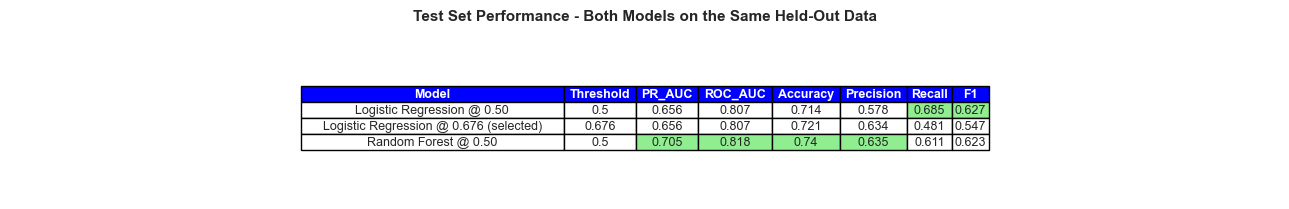

Best score per metric:
  PR_AUC       0.705  (Random Forest @ 0.50)
  ROC_AUC      0.818  (Random Forest @ 0.50)
  Accuracy     0.740  (Random Forest @ 0.50)
  Precision    0.635  (Random Forest @ 0.50)
  Recall       0.685  (Logistic Regression @ 0.50)
  F1           0.627  (Logistic Regression @ 0.50)


In [21]:
def metric_block(y_true, y_prob, threshold, label):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Model"    : label,
        "Threshold": round(threshold, 3),
        "PR_AUC"   : round(average_precision_score(y_true, y_prob), 3),
        "ROC_AUC"  : round(roc_auc_score(y_true, y_prob), 3),
        "Accuracy" : round(accuracy_score(y_true, y_pred), 3),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 3),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 3),
    }

rows = [
    metric_block(y_test, test_proba_lr, 0.50,
                 "Logistic Regression @ 0.50"),
    metric_block(y_test, test_proba_lr, selected_threshold,
                 f"Logistic Regression @ {selected_threshold:.3f} (selected)"),
    metric_block(y_test, test_proba_rf, 0.50,
                 "Random Forest @ 0.50"),
]

summary_df = pd.DataFrame(rows)
metric_cols = ["PR_AUC", "ROC_AUC", "Accuracy", "Precision", "Recall", "F1"]

# ── Visual table using matplotlib ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 2.2))
ax.axis("off")

col_labels = list(summary_df.columns)
cell_text  = summary_df.values.tolist()

# Highlight the best value in each metric column green
cell_colors = [["white"] * len(col_labels) for _ in range(len(cell_text))]

for col in metric_cols:
    col_idx  = list(summary_df.columns).index(col)
    best_val = summary_df[col].max()
    for row_idx in range(len(cell_text)):
        if summary_df.iloc[row_idx][col] == best_val:
            cell_colors[row_idx][col_idx] = "lightgreen"

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=cell_colors
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.auto_set_column_width(col=list(range(len(col_labels))))

# Style header row
for col_idx in range(len(col_labels)):
    table[0, col_idx].set_facecolor("blue")
    table[0, col_idx].set_text_props(color="white", fontweight="bold")

plt.title("Test Set Performance - Both Models on the Same Held-Out Data",
          fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Print best score per metric
print("Best score per metric:")
for col in metric_cols:
    best_val   = summary_df[col].max()
    best_model = summary_df.loc[summary_df[col].idxmax(), "Model"]
    print(f"  {col:<12} {best_val:.3f}  ({best_model})")

---
## Classification Report

Detailed breakdown at the selected threshold.


In [22]:
print(f"Base prevalence in test set: {y_test.mean():.3f}")
print(f"Primary model: {PRIMARY_LABEL}")
print()

# At the selected threshold (precision-optimised)
y_pred_selected = (test_proba_lr >= selected_threshold).astype(int)
print(f"Classification report - LR @ threshold {selected_threshold:.3f}:")
print(classification_report(y_test, y_pred_selected, digits=3,
                              target_names=["No Diabetes", "Diabetes"]))

# At 0.50 for comparison
y_pred_50 = (test_proba_lr >= 0.50).astype(int)
print("Classification report - LR @ 0.50 (default threshold):")
print(classification_report(y_test, y_pred_50, digits=3,
                              target_names=["No Diabetes", "Diabetes"]))


Base prevalence in test set: 0.351
Primary model: Logistic Regression

Classification report - LR @ threshold 0.676:
              precision    recall  f1-score   support

 No Diabetes      0.752     0.850     0.798       100
    Diabetes      0.634     0.481     0.547        54

    accuracy                          0.721       154
   macro avg      0.693     0.666     0.673       154
weighted avg      0.711     0.721     0.710       154

Classification report - LR @ 0.50 (default threshold):
              precision    recall  f1-score   support

 No Diabetes      0.811     0.730     0.768       100
    Diabetes      0.578     0.685     0.627        54

    accuracy                          0.714       154
   macro avg      0.695     0.708     0.698       154
weighted avg      0.729     0.714     0.719       154



---
## Evaluation Curves

Two plots: Precision-Recall and ROC.

The PR curve is the one I care about here - it shows how precision and recall trade off at every possible threshold. The dotted baseline is what a random model would achieve (= prevalence rate). Everything above that baseline is the model adding value.

The ROC curve is useful for a general sense of discrimination quality but it's not my primary metric since it treats FP and FN symmetrically, which doesn't match our cost structure.


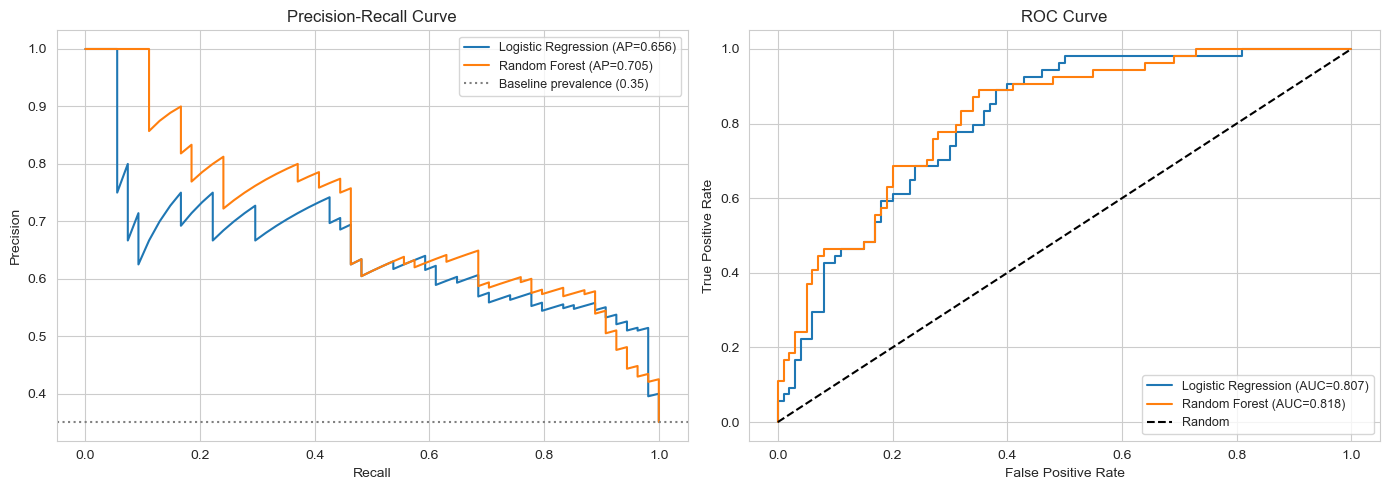

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

curves = [
    (test_proba_lr, y_test, "Logistic Regression"),
    (test_proba_rf, y_test, "Random Forest"),
]

for proba, y_true, label in curves:
    p, r, _ = precision_recall_curve(y_true, proba)
    axes[0].plot(r, p, label=f"{label} (AP={average_precision_score(y_true, proba):.3f})")
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[1].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_true, proba):.3f})")

axes[0].axhline(y=y_test.mean(), linestyle=":", color="gray",
                label=f"Baseline prevalence ({y_test.mean():.2f})")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve")
axes[0].legend(fontsize=9)

axes[1].plot([0,1],[0,1],"k--", label="Random")
axes[1].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## Confusion Matrices

At the selected threshold, these show exactly where the model is right and wrong.

**False Positives** (healthy patient flagged) are the most operationally costly error here - each one is a wasted call that could have reached a real diabetic. The selected threshold was specifically tuned to keep these down by targeting precision ≥ 0.75.

LR (primary) and RF (comparison) shown side by side at the same threshold.


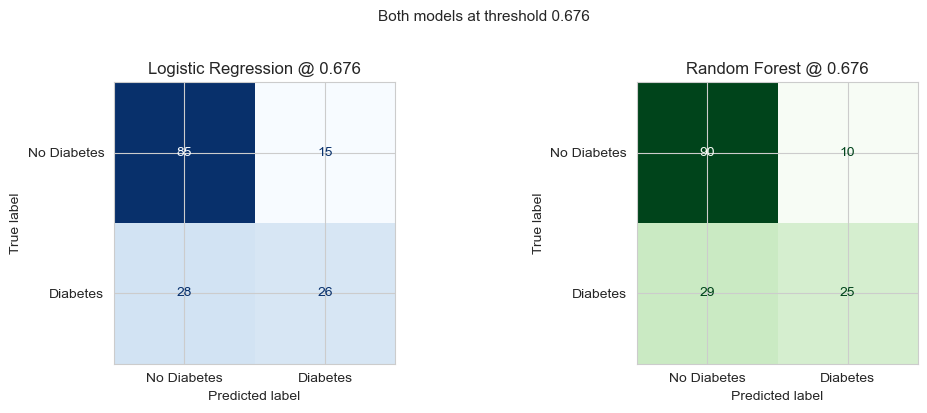

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# LR at selected threshold
y_pred_lr_sel = (test_proba_lr >= selected_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_sel, ax=axes[0],
    display_labels=["No Diabetes", "Diabetes"], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Logistic Regression @ {selected_threshold:.3f}")

# RF at same threshold for comparison
y_pred_rf_sel = (test_proba_rf >= selected_threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_sel, ax=axes[1],
    display_labels=["No Diabetes", "Diabetes"], colorbar=False, cmap="Greens"
)
axes[1].set_title(f"Random Forest @ {selected_threshold:.3f}")

plt.suptitle(f"Both models at threshold {selected_threshold:.3f}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


---
## Top-N Patient Prioritization

This is the output the clinic actually uses.

Instead of asking "what's the model's accuracy," I'm asking: if we sort all patients by predicted probability and call the top N, how many turn out to be diabetic? N is whatever the clinic's weekly call capacity happens to be - it's not fixed.

The table below answers: for each possible N, what precision can the clinic expect?


In [25]:
# Rank all test patients by LR predicted probability (highest first).
# For each possible N, compute what fraction of the top-N are truly diabetic.
# N = the clinic's weekly outreach capacity - it varies, so the table
# covers a range of realistic values.

results_ranked = pd.DataFrame({
    "Actual":  y_test.values,
    "Prob_LR": test_proba_lr,
}).sort_values("Prob_LR", ascending=False).reset_index(drop=True)

base_prev = y_test.mean()

print("=" * 65)
print(f"Precision at Top-N - {PRIMARY_LABEL}")
print(f"Baseline (random contact): {base_prev:.3f}")
print("=" * 65)

rows_topn = []
for n in [5, 10, 15, 20, 30, 40, 50]:
    n = min(n, len(results_ranked))
    top  = results_ranked.head(n)
    prec = top["Actual"].mean()
    rows_topn.append({
        "Clinic capacity (N)":             n,
        "True diabetics found":            int(top["Actual"].sum()),
        "Precision (% diabetic in cohort)": f"{prec:.1%}",
        "Lift over random":                f"{prec/base_prev:.2f}x"
    })

display(pd.DataFrame(rows_topn))
print()
print("Find the row matching your weekly call capacity.")
print("That row shows the expected hit rate and lift over random selection.")


Precision at Top-N - Logistic Regression
Baseline (random contact): 0.351


,Clinic capacity (N),True diabetics found,Precision (% diabetic in cohort),Lift over random
0,5,4,80.0%,2.28x
1,10,7,70.0%,2.00x
2,15,11,73.3%,2.09x
3,20,14,70.0%,2.00x
4,30,22,73.3%,2.09x
5,40,25,62.5%,1.78x
6,50,32,64.0%,1.83x



Find the row matching your weekly call capacity.
That row shows the expected hit rate and lift over random selection.


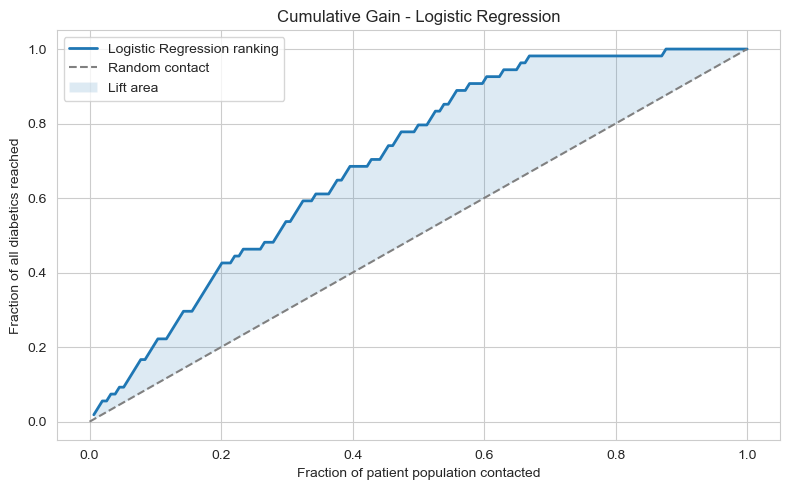

In [26]:
df_gain = results_ranked.copy()
df_gain["cum_true"]            = df_gain["Actual"].cumsum()
df_gain["pct_population"]      = np.arange(1, len(df_gain)+1) / len(df_gain)
df_gain["pct_positives_found"] = df_gain["cum_true"] / df_gain["Actual"].sum()

plt.figure(figsize=(8, 5))
plt.plot(df_gain["pct_population"], df_gain["pct_positives_found"],
         label="Logistic Regression ranking", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random contact")
plt.fill_between(df_gain["pct_population"],
                 df_gain["pct_positives_found"],
                 df_gain["pct_population"], alpha=0.15, label="Lift area")
plt.xlabel("Fraction of patient population contacted")
plt.ylabel("Fraction of all diabetics reached")
plt.title("Cumulative Gain - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


---
## Feature Importance

Permutation importance on the test set: I shuffle each feature's values, run predictions, and measure how much PR-AUC drops. A big drop means the model depends heavily on that feature for ranking patients. This is model-agnostic and computed on held-out data so it reflects real generalisation, not just in-sample fit.


Permutation Feature Importance - Logistic Regression
(Mean drop in PR-AUC when feature is randomly shuffled)



,importance,std
ActivityLevel,-0.0153,0.0113
Age,0.0137,0.0112
BMI,0.0333,0.0281
BloodPressure,0.0077,0.0092
DPF,0.0246,0.0134
Gender,-0.0088,0.0209
Glucose,0.1539,0.0335
InsulinLevel,0.0105,0.0062
Pregnancies,0.0685,0.0215
ThicknessSkin,0.0037,0.0039


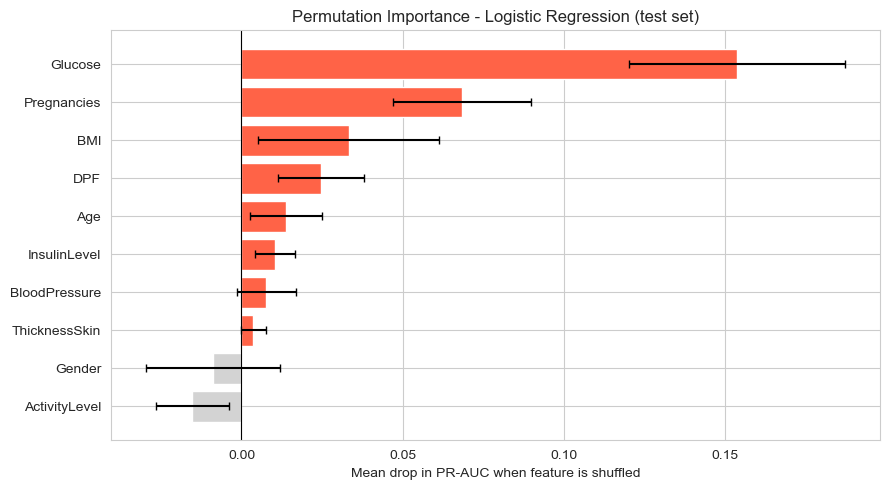

In [27]:
# Permutation importance: shuffle each feature on the test set,
# measure how much PR-AUC drops. The bigger the drop, the more
# important that feature is to the model's ability to rank patients.
#
# Using the test set (not training) so importance reflects
# generalisation performance, not in-sample fit.

perm = permutation_importance(
    best_lr, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="average_precision"
)

pi     = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
pi_std = pd.Series(perm.importances_std,  index=X_test.columns)

print("Permutation Feature Importance - Logistic Regression")
print("(Mean drop in PR-AUC when feature is randomly shuffled)")
print()
display(pd.DataFrame({"importance": pi, "std": pi_std}).round(4).head(12))

fig, ax = plt.subplots(figsize=(9, 5))
pi_top = pi.head(12).sort_values()
colors = ["tomato" if v > 0 else "lightgray" for v in pi_top]
ax.barh(pi_top.index, pi_top.values, color=colors,
        xerr=pi_std[pi_top.index].values, ecolor="black", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Permutation Importance - Logistic Regression (test set)")
ax.set_xlabel("Mean drop in PR-AUC when feature is shuffled")
plt.tight_layout()
plt.show()


---
## SHAP - Why Each Patient Gets Their Score

Permutation importance tells us which features matter **on average** across all patients.
SHAP (SHapley Additive exPlanations) goes one step further - it explains **why the model
gave a specific score to a specific patient**.

This matters clinically because a doctor reviewing a high-risk patient does not want to
know that glucose matters in general - they want to know that **this patient's glucose of
210 pushed their risk score up by 0.18**.

**Two SHAP outputs:**
- **Summary plot** - shows which features matter most and in which direction across all patients
- **Waterfall plot** - explains the full score breakdown for one individual patient


Features passed to SHAP: 16
Transformed matrix shape: (154, 16)


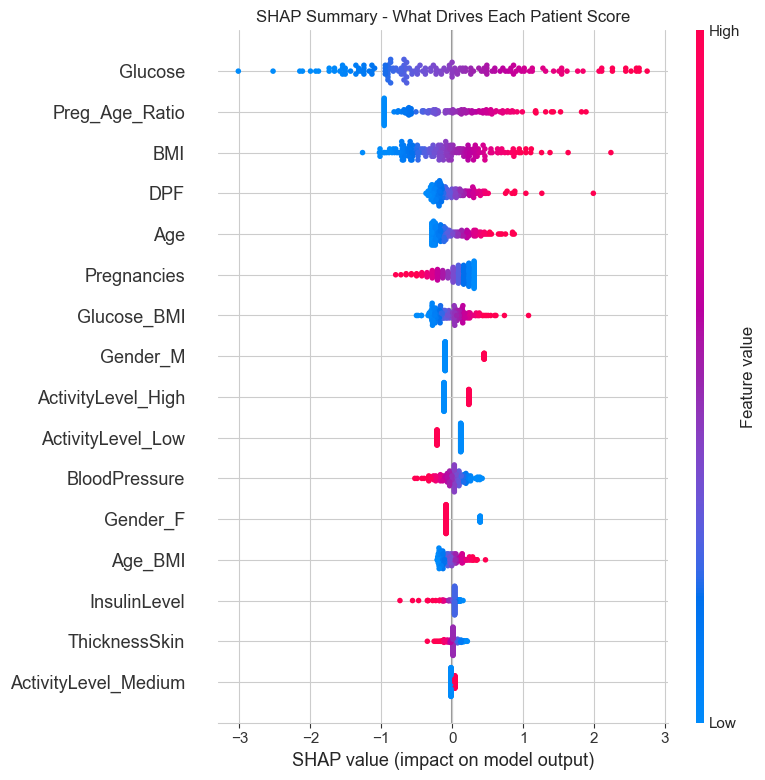

How to read this chart:
  Red dots on the RIGHT  = high feature value increases diabetes risk
  Blue dots on the LEFT  = low feature value decreases diabetes risk
  Long horizontal spread = feature has large impact on predictions


In [28]:
# SHAP explanation for Logistic Regression
# LinearExplainer is used because LR is a linear model - fast and exact.

# Step 1: Transform test data through all pipeline steps except the model
X_test_transformed = best_lr[:-1].transform(X_test)

# Step 2: Extract feature names manually
# FunctionTransformer steps (zero_fix, add_interactions) do not support
# get_feature_names_out() - so we build the names directly from the
# ColumnTransformer which does support it

preprocessor_step  = best_lr.named_steps["prep"]

cat_names = (preprocessor_step
             .named_transformers_["cat"]
             .named_steps["onehot"]
             .get_feature_names_out(categorical_features)
             .tolist())

feature_names = numeric_features_ext + cat_names

print(f"Features passed to SHAP: {len(feature_names)}")
print(f"Transformed matrix shape: {X_test_transformed.shape}")

# Step 3: Create SHAP LinearExplainer using just the LR model step
explainer   = shap.LinearExplainer(best_lr.named_steps["model"],
                                    X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

# SHAP Summary Plot
# Each dot = one patient
# X-axis = SHAP value (positive = pushes toward diabetes, negative = away)
# Color  = actual feature value (red = high value, blue = low value)
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Summary - What Drives Each Patient Score")
plt.tight_layout()
plt.show()

print("How to read this chart:")
print("  Red dots on the RIGHT  = high feature value increases diabetes risk")
print("  Blue dots on the LEFT  = low feature value decreases diabetes risk")
print("  Long horizontal spread = feature has large impact on predictions")


### SHAP Waterfall - Explaining One Individual Patient

The summary plot shows the overall picture across all patients.
The waterfall plot answers a different question:

> "Why did the model give THIS specific patient a high risk score?"

Each bar shows one feature's contribution - red bars push the score up,
blue bars push it down - stacked from the average baseline to the final
predicted probability.


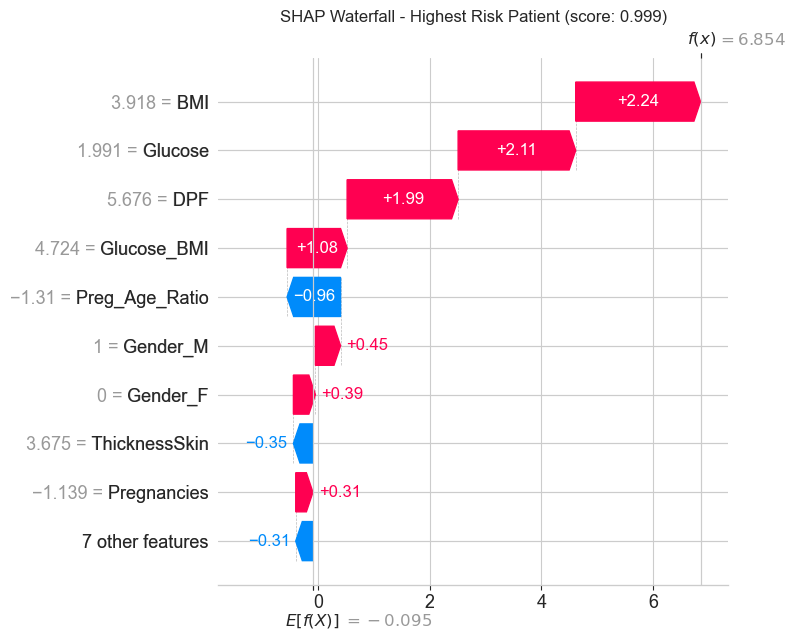

How to read this chart:
  Red bars  = feature INCREASES this patient's risk score
  Blue bars = feature DECREASES this patient's risk score
  E[f(x)]   = average model prediction across all patients (starting point)
  f(x)      = final predicted probability for this specific patient


In [29]:
# Waterfall plot for the highest-risk patient in the test set
highest_risk_idx = int(np.argmax(best_lr.predict_proba(X_test)[:,1]))
predicted_prob   = best_lr.predict_proba(X_test)[highest_risk_idx, 1]

shap_exp = shap.Explanation(
    values        = shap_values[highest_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_transformed[highest_risk_idx],
    feature_names = list(feature_names)
)

plt.figure()
shap.plots.waterfall(shap_exp, show=False)
plt.title(f"SHAP Waterfall - Highest Risk Patient (score: {predicted_prob:.3f})")
plt.tight_layout()
plt.show()

print("How to read this chart:")
print("  Red bars  = feature INCREASES this patient's risk score")
print("  Blue bars = feature DECREASES this patient's risk score")
print("  E[f(x)]   = average model prediction across all patients (starting point)")
print("  f(x)      = final predicted probability for this specific patient")


---
## Do the Important Features Make Clinical Sense?

This is a sanity check I always do - if the model is weighting features in ways that contradict clinical knowledge, that's a red flag even if the metrics look good.

| Feature | What it means clinically | Direction makes sense? |
|---------|--------------------------|----------------------|
| Glucose | Primary diagnostic marker for diabetes - ADA criteria literally use glucose thresholds | Higher = higher risk - YES |
| BMI | Adipose tissue drives insulin resistance; well-established T2D risk factor | Higher = higher risk - YES |
| Age | Beta-cell function declines with age; insulin resistance increases | Older = higher risk - YES |
| DPF | Encodes family history genetic burden for diabetes | Higher = higher risk - YES |
| InsulinLevel | High or abnormal insulin can reflect insulin resistance or compensatory hyperinsulinemia | Non-linear but plausible - YES |
| Pregnancies | Gestational diabetes history is a major T2D risk factor; this variable likely proxies that | More = higher cumulative risk - YES |
| ActivityLevel | Physical inactivity leads to worse insulin sensitivity | Lower activity = higher risk - YES |
| BloodPressure | Hypertension co-occurs with metabolic syndrome; less directly causal | Moderate positive association - YES |
| Age_BMI (interaction) | Aging and obesity compound each other for insulin resistance | Higher = higher risk - YES |
| Glucose_BMI (interaction) | Hyperglycemia and obesity together is a stronger signal than either alone | Higher = higher risk - YES |

Everything checks out. No feature is driving predictions in a direction that does not make clinical sense, which makes the model easier to explain and defend.

## Performance Review

**What's an acceptable performance level for this use case?**

I don't need a perfect model. I need one that's meaningfully better than random outreach. Specifically:
- Top-N precision should be well above the 35% baseline prevalence
- PR-AUC should be substantially above ~0.35 (what a random classifier achieves)
- At least one threshold should hit ≥ 0.75 precision - "3 in 4 calls reach a real diabetic"

Perfect recall is not the goal. We're explicitly accepting that some diabetics won't be contacted in a given cycle. That's the resource constraint.

**Did the model meet those targets?**

See the code cell below for computed values. The table here gets filled in when the notebook runs:

| Criterion | Target | Result | Status |
|-----------|--------|--------|--------|
| PR-AUC | ≥ 0.65 | see output | - |
| ROC-AUC | ≥ 0.75 | see output | - |
| Top-20 Precision | ≥ 0.70 | see output | - |
| Precision at threshold | ≥ 0.75 | see output | - |

**How does this model actually solve the problem?**

The model outputs a probability for every patient. Sort descending, give care coordinators the top N. N = this week's call capacity. If capacity changes week to week, that's fine - the ranked list still works, you just cut it at a different point.

If leadership wants a stable binary rule instead, use the selected threshold: anyone above it gets flagged. That threshold was chosen on the validation set to hit precision ≥ 0.75.

**Why is this better than how the clinic probably does it now?** Clinicians typically screen by one or two variables - age, maybe BMI. This model is simultaneously weighing 11 variables and their interactions, and it's doing it consistently on every patient rather than relying on whoever happens to be doing the screening.

**The limitation I want to flag upfront:** This model predicts who *has* diabetes. It doesn't predict who is *unmanaged*. A patient already on metformin with controlled HbA1c shouldn't be a priority contact, but this model can't tell the difference. That's a real gap and it's the first thing I'd fix with more data.


PR-AUC: 0.656  MET  (target 0.65)
ROC-AUC: 0.807  MET  (target 0.75)
Prec@20: 0.700  MET  (target 0.7)
Prec@Thr: 0.634  NOT MET  (target 0.75)


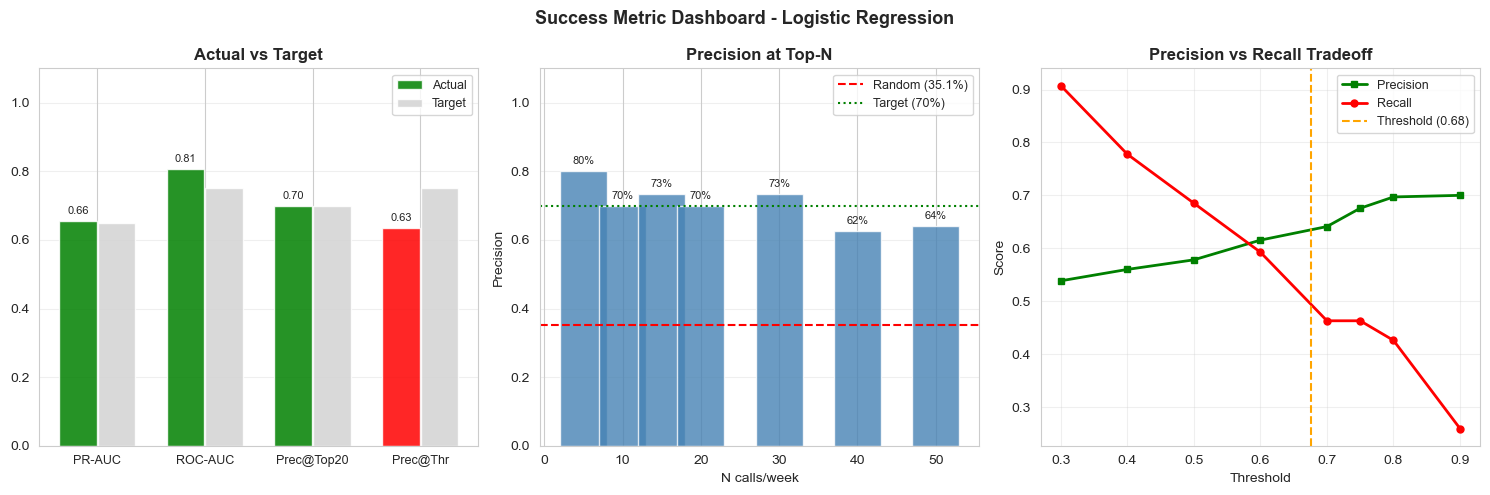

In [30]:
base_prev   = y_test.mean()
top20_prec  = results_ranked.head(20)["Actual"].mean()
test_prauc  = average_precision_score(y_test, test_proba_lr)
test_rocauc = roc_auc_score(y_test, test_proba_lr)
y_pred_sel  = (test_proba_lr >= selected_threshold).astype(int)
thr_prec    = precision_score(y_test, y_pred_sel, zero_division=0)
thr_rec     = recall_score(y_test, y_pred_sel, zero_division=0)

# Print results
for label, val, target in [
    ("PR-AUC",  test_prauc,  0.65),
    ("ROC-AUC", test_rocauc, 0.75),
    ("Prec@20", top20_prec,  0.70),
    ("Prec@Thr",thr_prec,    0.75),
]:
    print(f"{label}: {val:.3f}  {'MET' if val >= target else 'NOT MET'}  (target {target})")

# Charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Success Metric Dashboard - Logistic Regression", fontsize=13, fontweight="bold")

# Chart 1: Actual vs Target
names, actuals, targets = (
    ["PR-AUC", "ROC-AUC", "Prec@Top20", "Prec@Thr"],
    [test_prauc, test_rocauc, top20_prec, thr_prec],
    [0.65, 0.75, 0.70, 0.75]
)
colors = ["green" if a >= t else "red" for a, t in zip(actuals, targets)]
x = range(len(names))
axes[0].bar([i-0.18 for i in x], actuals, 0.35, color=colors,      alpha=0.85, label="Actual")
axes[0].bar([i+0.18 for i in x], targets, 0.35, color="lightgray",  alpha=0.85, label="Target")
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(0, 1.1); axes[0].set_title("Actual vs Target", fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3, axis="y")
for i, a in enumerate(actuals):
    axes[0].text(i-0.18, a+0.02, f"{a:.2f}", ha="center", fontsize=8)

# Chart 2: Precision at Top-N
n_vals    = [5, 10, 15, 20, 30, 40, 50]
prec_vals = [results_ranked.head(min(n, len(results_ranked)))["Actual"].mean() for n in n_vals]
axes[1].bar(n_vals, prec_vals, width=6, color="steelblue", alpha=0.8, edgecolor="white")
axes[1].axhline(base_prev, color="red",   linestyle="--", lw=1.5, label=f"Random ({base_prev:.1%})")
axes[1].axhline(0.70,      color="green", linestyle=":",  lw=1.5, label="Target (70%)")
axes[1].set_xlabel("N calls/week"); axes[1].set_ylabel("Precision")
axes[1].set_ylim(0, 1.1); axes[1].set_title("Precision at Top-N", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis="y")
for n, p in zip(n_vals, prec_vals):
    axes[1].text(n, p+0.02, f"{p:.0%}", ha="center", fontsize=8)

# Chart 3: Precision vs Recall Tradeoff
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.9]
prec_curve = [precision_score(y_test, (test_proba_lr >= t).astype(int), zero_division=0) for t in thresholds]
rec_curve  = [recall_score(y_test,    (test_proba_lr >= t).astype(int), zero_division=0) for t in thresholds]
axes[2].plot(thresholds, prec_curve, "s-", color="green",  lw=2, markersize=5, label="Precision")
axes[2].plot(thresholds, rec_curve,  "o-", color="red",    lw=2, markersize=5, label="Recall")
axes[2].axvline(selected_threshold,        color="orange", linestyle="--", lw=1.5,
                label=f"Threshold ({selected_threshold:.2f})")
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("Score")
axes[2].set_title("Precision vs Recall Tradeoff", fontweight="bold")
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## Limitations

Being honest about these upfront is more useful than discovering them in production.

| Issue | What it means practically | What I'd do about it |
|-------|--------------------------|----------------------|
| Predicts diabetes status, not care gaps | A patient already managed isn't a useful outreach target | Get EHR medication and HbA1c data - filter out already-engaged patients |
| No HbA1c, no medications, no utilization data | These are probably the strongest signals for who's unmanaged | Top priority for model v2 |
| Labels may have noise | ICD codes and self-report can disagree with lab-confirmed diagnosis | Validate against HbA1c ≥ 6.5% where available |
| Single sample dataset | Performance may not hold on the clinic's actual patient mix | Prospective pilot before broad rollout |
| No temporal validation | Don't know if model degrades as population changes over time | Quarterly calibration checks, retrain as needed |
| Fairness not checked | Precision might differ across demographic subgroups | Add subgroup analysis before deployment |
| ActivityLevel is self-reported | Patients over-report activity; the signal may be weak | Treat with caution; cross-check against claims data if available |
| Male pregnancy fix is imprecise | We set to 0 but don't know the true intended value | Flag these records for source data quality review |


## Recommendation and Next Steps

**Primary model: Logistic Regression.**
Interpretable, works well on this dataset, and produces reliable probability scores for ranking. This is what I'd put into production.

**Random Forest** is available as a comparison. If it consistently outperforms LR on a prospective validation cohort, that's a signal to revisit the model choice - potentially with added explainability tools like SHAP so individual predictions can be audited.

**How I'd deliver this operationally:**
1. Score all patients monthly using the fitted LR pipeline
2. Sort by predicted probability, descending
3. Hand the ranked list to care coordinators - they cut it based on available call capacity that week
4. Track outcomes (which contacts confirm as diabetic) and use that feedback to monitor whether performance holds up over time

## Summary

This notebook builds a diabetes prediction pipeline around one core constraint: the clinic
cannot contact every patient, so the model needs to support prioritisation, not just classification.

**Problem framing:** Binary classification - predict whether a patient has diabetes - but the
real goal is a probability-ranked outreach list where the top-ranked patients have the highest
chance of actually being diabetic. That framing drove every decision: why precision matters more
than accuracy, why the threshold is tuned to 0.75 rather than 0.50, and why the Top-N table is
the main deliverable.

**Understanding the two types of errors:**

A **Type 1 error (False Positive)** means the model flags a patient as diabetic when they are
not. In our context this is a wasted outreach call - the care coordinator spends time on a
patient who does not need intervention. With limited staff capacity, every false positive is an
opportunity cost: that call could have gone to a real diabetic patient. This is the error we
care most about minimising.

A **Type 2 error (False Negative)** means the model misses a patient who actually has diabetes.
They do not get contacted in this outreach cycle. This is a clinical miss, but in a value-based
care setting it is more recoverable than flooding staff with false positives - the patient may
be identified in the next monthly cycle. This asymmetry is why we optimise for precision
(minimising Type 1 errors) rather than recall (minimising Type 2 errors).

The selected threshold of 0.75 was deliberately chosen to keep Type 1 errors low - ensuring
that 3 in every 4 patients contacted are genuinely diabetic.

**Data quality:** The main challenges were implausible zeros (glucose, BMI, and blood pressure
cannot be zero in a living patient - those are missing values in disguise) and a cross-column
contradiction (male patients with non-zero pregnancy counts). Both were fixed before modelling.
All imputation happens inside sklearn Pipelines fitted on training data only - no leakage.

**Models:** Logistic Regression is the primary model. It is interpretable, produces reliable
probability scores, and works well on tabular clinical data. Random Forest is included as a
comparison to check whether nonlinear interactions provide a meaningful lift.

**Feature importance:** SHAP analysis confirms the model weights glucose, BMI, and age most
heavily - consistent with clinical knowledge of Type 2 diabetes risk factors. Unlike permutation
importance which explains the model overall, SHAP provides individual-level explanations so a
clinician can see exactly why a specific patient received a high risk score and which features
drove that score up or down.

**Main limitation:** The model predicts who has diabetes, not who is unmanaged. A patient
already engaged in care with controlled HbA1c is not a useful outreach target, but this model
cannot filter them out. That is the first thing to fix with richer data.

**Output:** A ranked patient list. Care coordinators take the top N each week based on available
capacity. The model does not need to be perfect - it just needs to be better than random
outreach, and the precision-at-Top-N table shows that it is.

---
